# Twisted-graphene HAADF-STEM denoising

This notebook compares three pretrained models on the included 30-degree twisted-graphene HAADF-STEM example:

- SFIN HAADF (`sfin_haadf`)
- AtomSegNet U-Net (`unet_denoise`)
- AtomSegNet nested U-Net (`nested_unet_denoise`)

For each light, medium, and heavy noise level, it reports MSE, PSNR, and SSIM against the clean image and displays clean, noisy, and denoised images in a row.

## Model ranges

| Model | Input passed to model | Raw output handling |
|---|---|---|
| SFIN HAADF | Float `[0, 255]` | Clip to `[0, 255]`, then divide by 255 |
| AtomSegNet U-Net | Float `[0, 1]` | Clip sigmoid output to `[0, 1]` |
| AtomSegNet nested U-Net | Float `[0, 1]` | Convert tanh output with `(output + 1) / 2`, then clip |

The AtomSegNet ranges reproduce the released GUI inference utility. Its nested U-Net training pipeline used a different `[-1, 1]` normalization, so the upstream training and inference code are inconsistent. Metric calculations below always use arrays in `[0, 1]`.

In [1]:
import os

# Work around duplicate OpenMP runtimes in the tested Windows Conda environment.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

In [2]:
def find_repository_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Could not find the denoise-learn repository root")


REPOSITORY_ROOT = find_repository_root(Path.cwd())
if str(REPOSITORY_ROOT) not in sys.path:
    sys.path.insert(0, str(REPOSITORY_ROOT))

from denoiselearn.metrics import evaluate_denoising
from denoiselearn.models import load_pretrained

DATA_DIR = REPOSITORY_ROOT / "data" / "twisted_graphene_30deg"
CHECKPOINT_DIR = REPOSITORY_ROOT / "checkpoints"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Data directory: {DATA_DIR.relative_to(REPOSITORY_ROOT)}")
print(f"Device: {DEVICE}")

Data directory: data\twisted_graphene_30deg
Device: cuda


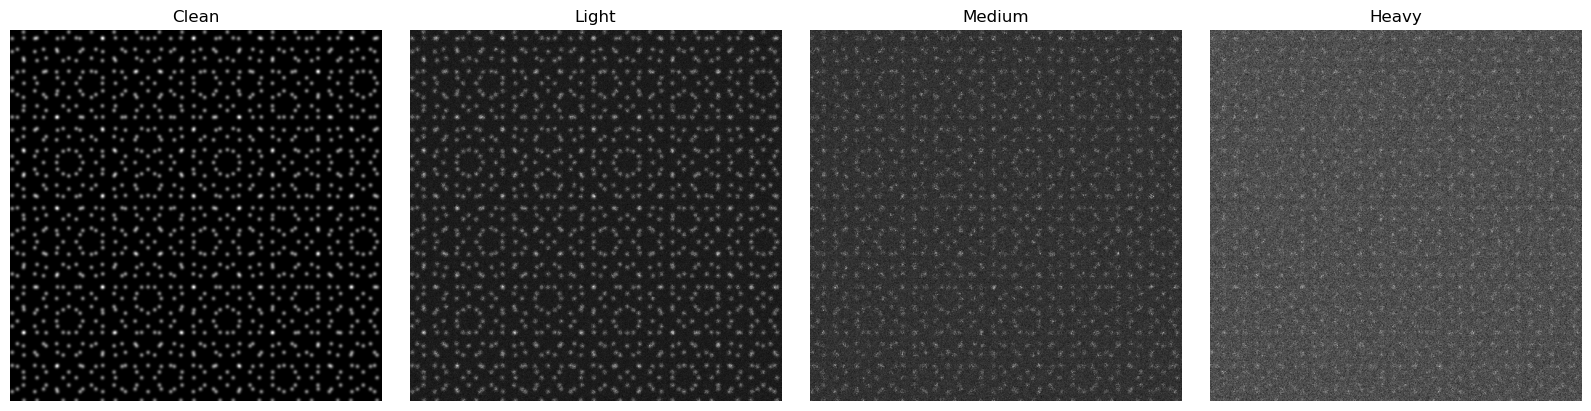

In [3]:
def load_array(filename: str) -> np.ndarray:
    array = np.load(DATA_DIR / filename, allow_pickle=False).astype(np.float32)
    if array.ndim != 2:
        raise ValueError(f"Expected a 2-D array, got {array.shape}: {filename}")
    if not np.isfinite(array).all():
        raise ValueError(f"Non-finite values found in {filename}")
    if array.min() < 0.0 or array.max() > 1.0:
        raise ValueError(f"Expected values in [0, 1]: {filename}")
    return array


clean = load_array("twisted_graphene_30deg_clean.npy")
noisy_images = {
    level: load_array(f"twisted_graphene_30deg_{level}_noisy.npy")
    for level in ("light", "medium", "heavy")
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)
for axis, (title, image) in zip(
    axes,
    [("Clean", clean), *[(level.title(), image) for level, image in noisy_images.items()]],
):
    axis.imshow(image, cmap="gray")
    axis.set_title(title)
    axis.set_axis_off()
plt.show()

In [4]:
MODEL_CONFIGS = {
    "SFIN HAADF": {
        "identifier": "sfin_haadf",
        "checkpoint": CHECKPOINT_DIR / "sfin" / "sfin_enhance_haadf_500.pth",
    },
    "AtomSegNet U-Net": {
        "identifier": "unet_denoise",
        "checkpoint": CHECKPOINT_DIR / "atomsegnet" / "denoise.pth",
    },
    "AtomSegNet nested U-Net": {
        "identifier": "nested_unet_denoise",
        "checkpoint": CHECKPOINT_DIR / "atomsegnet" / "Gen1-noNoise.pth",
    },
}


def resolve_checkpoint(path: Path):
    return path if path.is_file() else None


models = {
    label: load_pretrained(
        config["identifier"],
        checkpoint_path=resolve_checkpoint(config["checkpoint"]),
        device=DEVICE,
    )
    for label, config in MODEL_CONFIGS.items()
}

list(models)

['SFIN HAADF', 'AtomSegNet U-Net', 'AtomSegNet nested U-Net']

In [5]:
def run_model(model, identifier: str, image: np.ndarray) -> np.ndarray:
    tensor = torch.from_numpy(image.copy()).unsqueeze(0).unsqueeze(0).to(DEVICE)

    if identifier == "sfin_haadf":
        tensor = tensor * 255.0

    with torch.inference_mode():
        output = model(tensor)

    if identifier == "sfin_haadf":
        output = output.clamp(0.0, 255.0) / 255.0
    elif identifier == "nested_unet_denoise":
        output = ((output + 1.0) / 2.0).clamp(0.0, 1.0)
    else:
        output = output.clamp(0.0, 1.0)

    return output.squeeze(0).squeeze(0).cpu().numpy()


denoised_images = {
    model_label: {
        noise_level: run_model(
            models[model_label],
            MODEL_CONFIGS[model_label]["identifier"],
            noisy,
        )
        for noise_level, noisy in noisy_images.items()
    }
    for model_label in models
}

In [6]:
rows = []
for model_label, outputs in denoised_images.items():
    for noise_level, denoised in outputs.items():
        results = evaluate_denoising(
            noisy_images[noise_level],
            denoised,
            clean,
            data_range=1.0,
        )
        for stage in ("noisy", "denoised", "improvement"):
            rows.append(
                {
                    "model": model_label,
                    "noise": noise_level,
                    "image": stage,
                    "mse": results[stage]["mse"],
                    "psnr": results[stage]["psnr"],
                    "ssim": results[stage]["ssim"],
                }
            )

metrics = pd.DataFrame(rows)
display(metrics.round({"mse": 6, "psnr": 3, "ssim": 6}))

,model,noise,image,mse,psnr,ssim
0,SFIN HAADF,light,noisy,0.011190,19.512,0.357335
1,SFIN HAADF,light,denoised,0.004215,23.752,0.746327
2,SFIN HAADF,light,improvement,0.006975,4.240,0.388992
3,SFIN HAADF,medium,noisy,0.034444,14.629,0.160805
4,SFIN HAADF,medium,denoised,0.009965,20.015,0.543373
5,SFIN HAADF,medium,improvement,0.024478,5.386,0.382568
6,SFIN HAADF,heavy,noisy,0.082183,10.852,0.083252
7,SFIN HAADF,heavy,denoised,0.011711,19.314,0.151003
8,SFIN HAADF,heavy,improvement,0.070473,8.462,0.067751
9,AtomSegNet U-Net,light,noisy,0.011190,19.512,0.357335


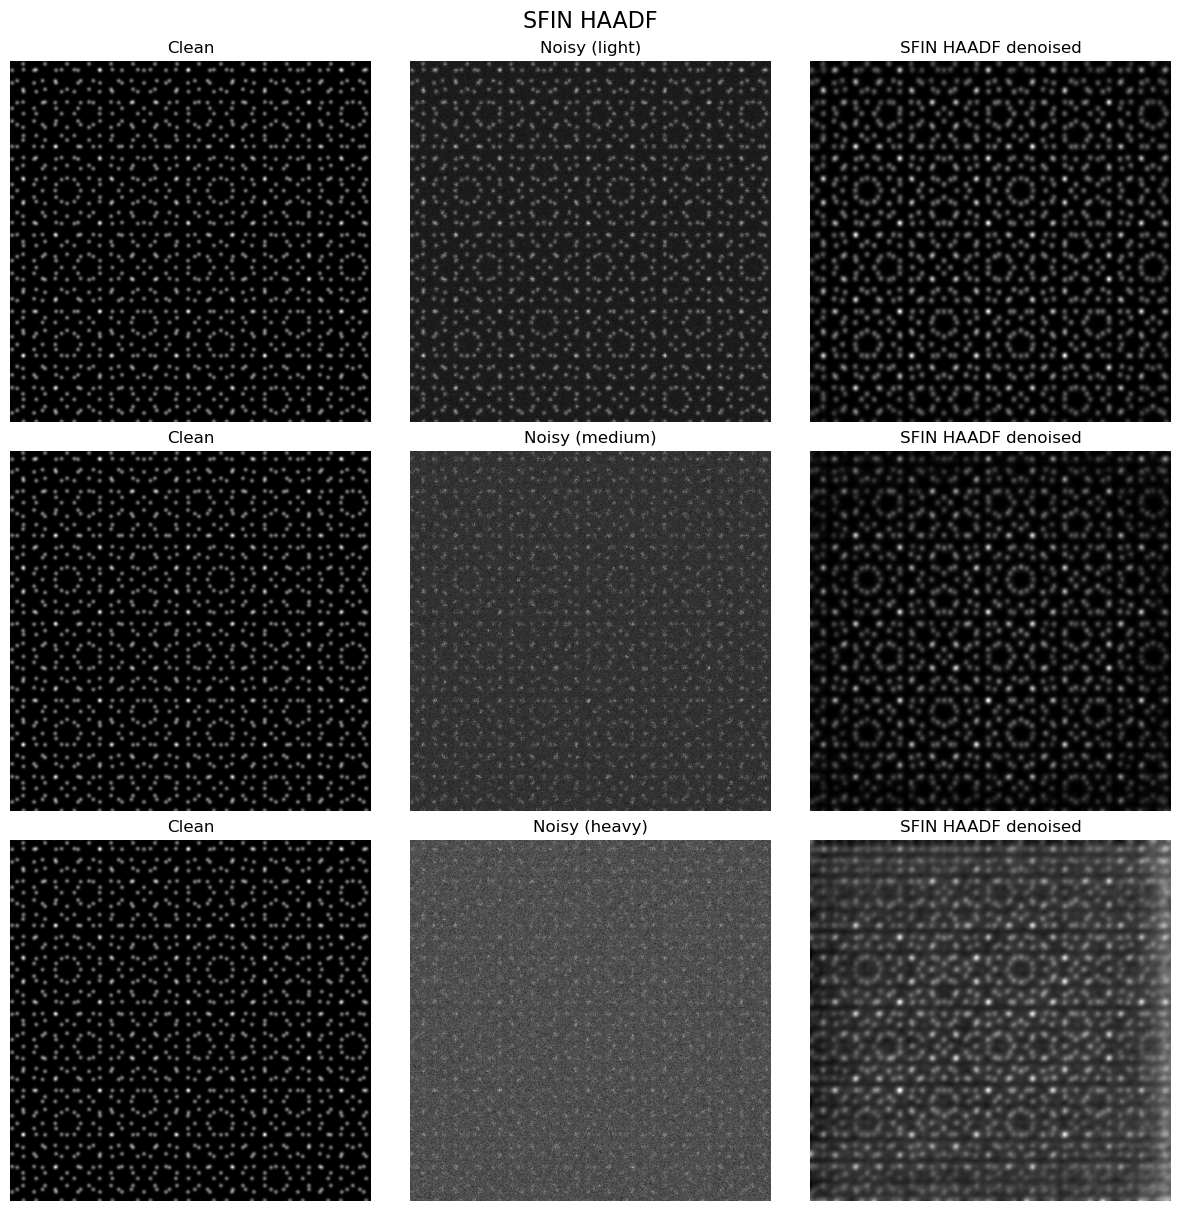

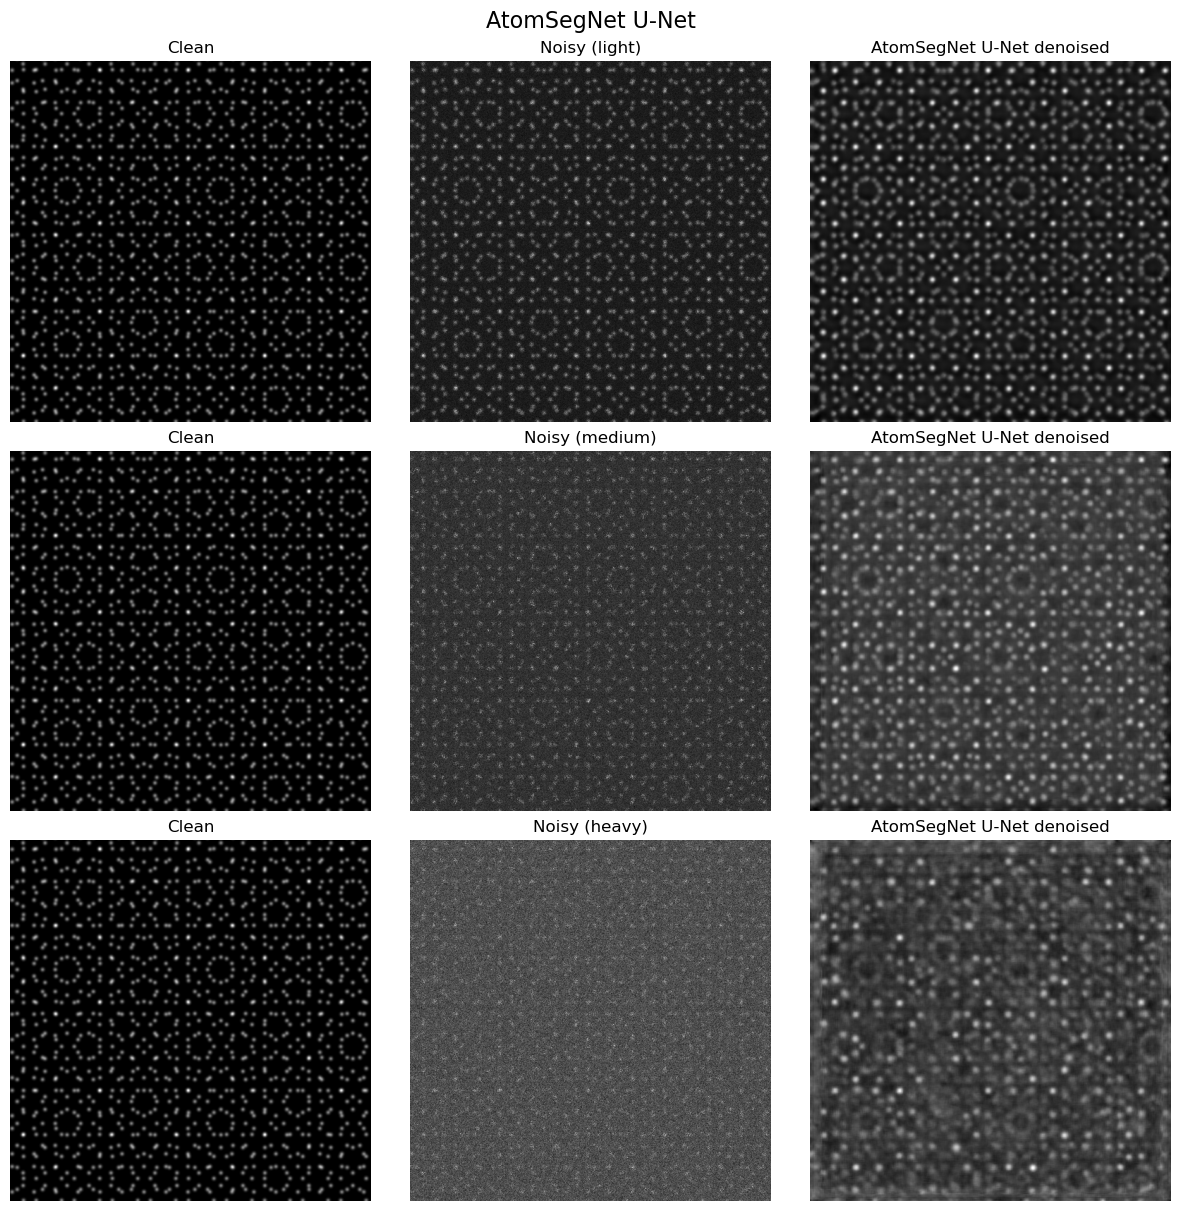

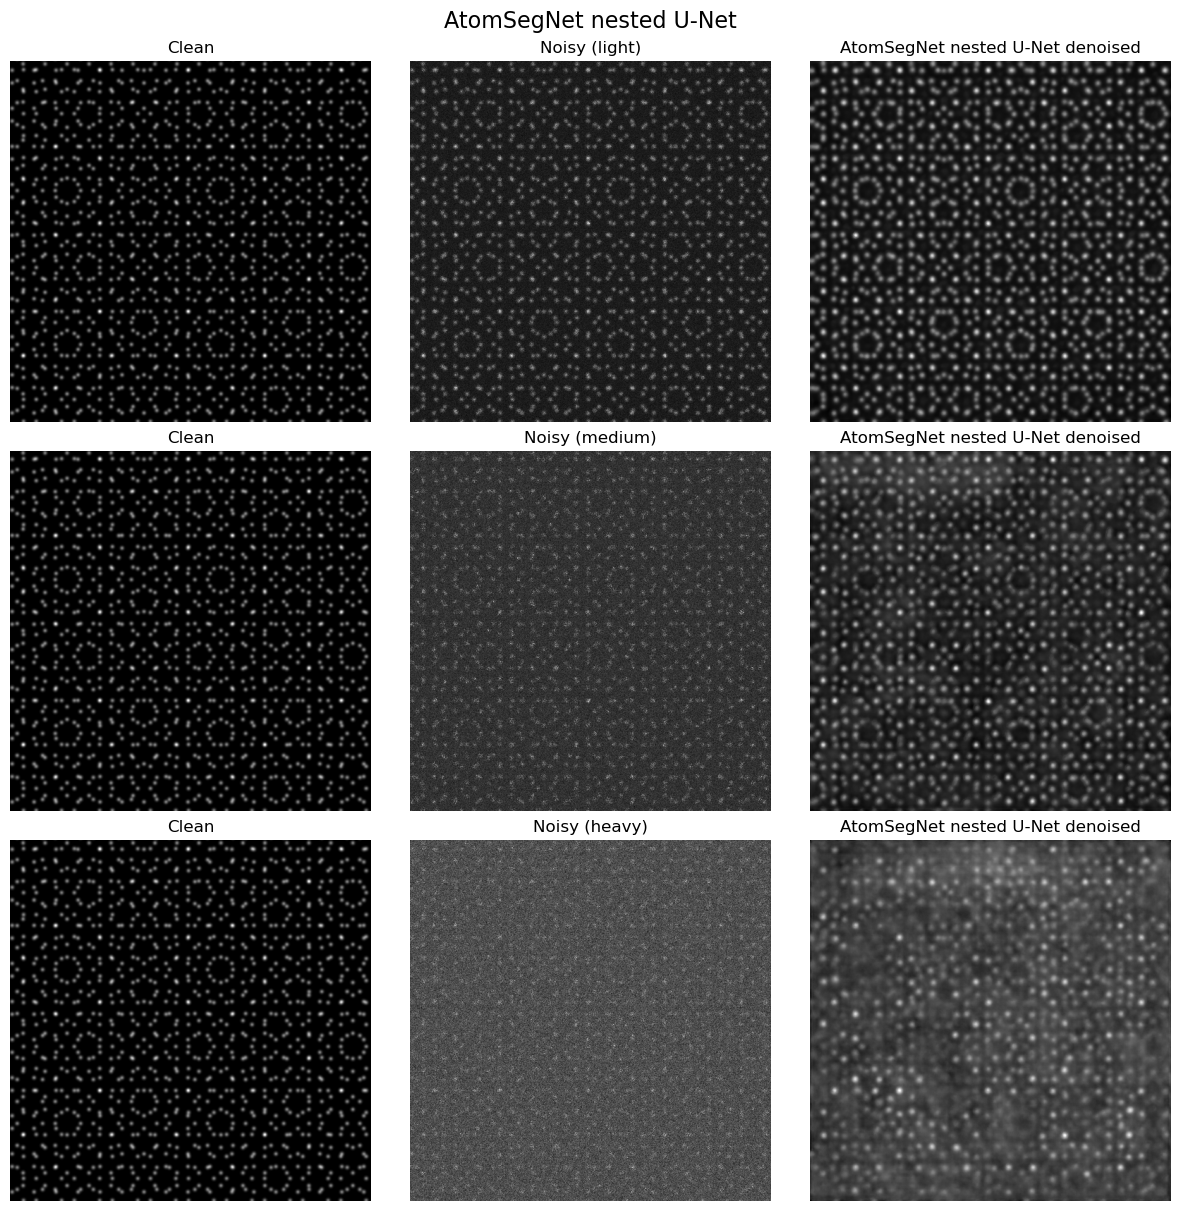

In [7]:
for model_label, outputs in denoised_images.items():
    figure, axes = plt.subplots(3, 3, figsize=(12, 12), constrained_layout=True)
    for row, noise_level in enumerate(("light", "medium", "heavy")):
        panels = (
            ("Clean", clean),
            (f"Noisy ({noise_level})", noisy_images[noise_level]),
            (f"{model_label} denoised", outputs[noise_level]),
        )
        for axis, (title, image) in zip(axes[row], panels):
            axis.imshow(image, cmap="gray")
            axis.set_title(title)
            axis.set_axis_off()
    figure.suptitle(model_label, fontsize=16)
    plt.show()

## Interpretation

The SFIN HAADF checkpoint improves the reported metrics on this example. The AtomSegNet checkpoints do not transfer consistently to this HAADF dataset, especially by SSIM. This is evidence of domain mismatch rather than a general ranking of the architectures.

Keep the raw images and inspect atomic positions and relative intensities in addition to aggregate metrics. Each displayed panel is independently autoscaled by Matplotlib for visibility, so visual brightness is not a shared quantitative scale.